# Inference with loaded experts and a ReliFuse checkpoint

Use this path after training. The demo creates temporary expert and ReliFuse checkpoints so the notebook is runnable without committing weights to git.


In [1]:
import sys
import tempfile
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
sys.path.insert(0, str(ROOT))

import torch

from examples.loaded_expert_demo import (
    create_demo_checkpoints,
    load_expert_models,
    make_synthetic_vessel_split,
    plot_fusion_case,
    predict_stack,
)
from relifuse import ReliFuse, TrainingConfig, expert_dice_scores, fit, seed_everything

seed_everything(7)

from relifuse import use_all_experts


In [2]:
# Demo data: license-clean synthetic vessel masks.
# Replace this cell with your real Dataset/DataLoader. Keep outputs as [B,1,H,W].
train_images, train_masks = make_synthetic_vessel_split(10, seed=10)
validation_images, validation_masks = make_synthetic_vessel_split(5, seed=20)
test_images, test_masks = make_synthetic_vessel_split(3, seed=30)

print(train_images.shape, validation_images.shape, test_images.shape)


torch.Size([10, 1, 48, 48]) torch.Size([5, 1, 48, 48]) torch.Size([3, 1, 48, 48])


In [3]:
# Demo setup: create expert checkpoints in tempdir and load them like user weights.
tmp = tempfile.TemporaryDirectory()
expert_specs = [
    ("tiny_cnn_a", "cnn", 6, 1),
    ("tiny_cnn_b", "cnn", 8, 2),
    ("tiny_context", "context", 10, 1),
]
checkpoints = create_demo_checkpoints(tmp.name, train_images, train_masks, expert_specs)
models = load_expert_models(checkpoints)

train_predictions = predict_stack(models, train_images)
validation_predictions = predict_stack(models, validation_images)
quality = expert_dice_scores(validation_predictions, validation_masks)
bank = use_all_experts(train_predictions, requested_experts=len(models))

fusion = ReliFuse(num_experts=bank.num_experts, expert_scores=quality)
fit(
    fusion,
    train_predictions,
    train_masks,
    validation_predictions,
    validation_masks,
    config=TrainingConfig(epochs=2, batch_size=2, patience=2),
)

relifuse_checkpoint = Path(tmp.name) / "relifuse_demo.pt"
torch.save({"state_dict": fusion.state_dict(), "expert_scores": quality}, relifuse_checkpoint)
print(relifuse_checkpoint)


/var/folders/bm/6xws8v017wj6kvp96xcm_rkdfhvql5/T/tmp6_oe9zdf/relifuse_demo.pt


torch.Size([3, 1, 48, 48]) torch.Size([3, 1, 48, 48])


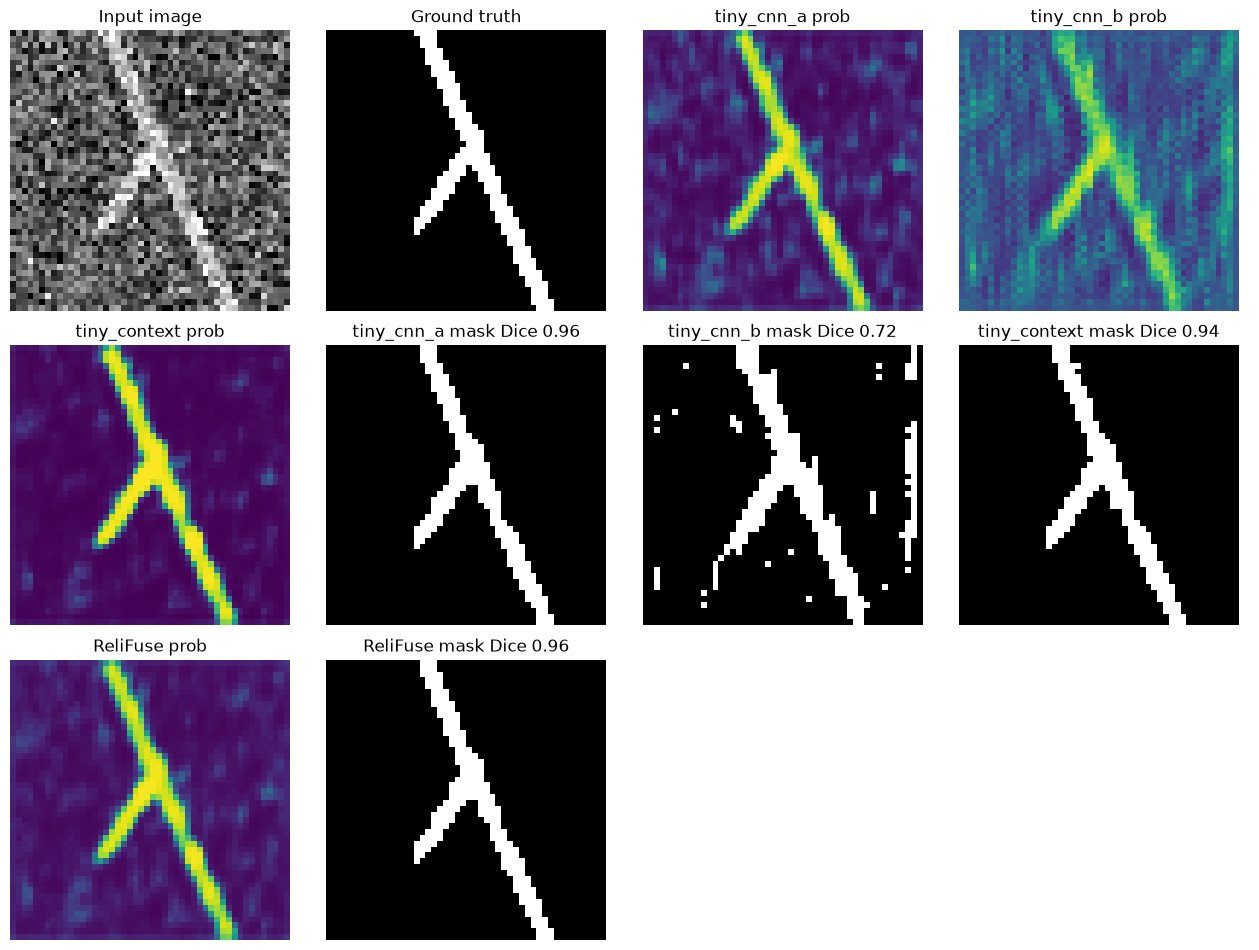

In [4]:
# Real inference starts here: load expert weights, produce posteriors, load ReliFuse.
inference_models = load_expert_models(checkpoints)
test_predictions = predict_stack(inference_models, test_images)

payload = torch.load(relifuse_checkpoint, map_location="cpu", weights_only=True)
inference_fusion = ReliFuse(num_experts=test_predictions.shape[1], expert_scores=payload["expert_scores"])
inference_fusion.load_state_dict(payload["state_dict"])
inference_fusion.eval()

with torch.inference_mode():
    probability = inference_fusion.fuse(test_predictions)
    mask = inference_fusion.fuse(test_predictions, threshold=0.5)

print(probability.shape, mask.shape)
plot_fusion_case(
    test_images[0],
    test_masks[0],
    test_predictions[0],
    probability[0],
    expert_names=[checkpoint.name for checkpoint in checkpoints],
)
tmp.cleanup()
